# I. Analyse Exploratoire des Données (EDA)

## Contexte
Ce notebook est dédié à la phase d'**exploration et de préparation des données** pour le projet **TelcoWave Customer Churn**. L'objectif final est de concevoir un modèle de scoring capable d'estimer la probabilité de résiliation de chaque client. Dans un contexte de budget marketing limité, cet outil permettra de cibler en priorité les profils les plus à risque. Ce travail préliminaire pose les bases des étapes suivantes de Feature Engineering et de modélisation.

## Objectifs
* **Valider la qualité et la cohérence des données** : identifier et traiter les valeurs manquantes (NaN), vérifier les types de variables et détecter les éventuelles valeurs aberrantes (*outliers*).
* **Identifier les relations clés** : analyser les corrélations et les liens majeurs entre les caractéristiques des clients et la variable cible (le churn).
* **Sélectionner les variables** : isoler les fonctionnalités les plus prometteuses et discriminantes pour optimiser les performances du futur modèle.

## Import des librairies

In [1]:
# Packages de manipulation des tableaux et DataFrames
import pandas as pd
# package pour la visualisation
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import plotly.express as px

# forcer l'affichage dans github des images Plotly interactifs
import plotly.io as pio
pio.renderers.default = "png"

# Package sklearn
from sklearn.model_selection import train_test_split


## 1. Chargement du jeu de données

In [2]:
# Chargement du fichier de données
df_customer = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Il y a {df_customer.shape[0]} lignes et {df_customer.shape[1]} colonnes dans le DataFrame initial.")

#Affichage des 5 premières lignes de df_customer
df_customer.head()

#Affichage des 5 dernières ligne df_customer
#df_customer.tail()



Il y a 7043 lignes et 21 colonnes dans le DataFrame initial.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Analyse exploratoire globale du dataset

## 2.1. inspection initiale des données

In [3]:
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

La variable **TotalCharges** est enregistrée en tant que chaîne de caractères (str) alors qu'elle contient des valeurs numériques (float). Nous allons modifier son type pour la convertir en numérique.

In [4]:
#Changement de type de 'TotalCharges'
df_customer['TotalCharges'] = pd.to_numeric(df_customer['TotalCharges'], errors='coerce')

df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

L'analyse avec `df.info()` montre que la variable **TotalCharges** contient 11 valeurs manquantes (environ 0,16% du dataset). 
Nous traiterons ces données manquantes (imputation) après la séparation en ensembles de train et de test afin d'éviter toute fuite de données.  

## 2.2 Dictionnaire des données

Le jeu de données que nous utilisons contient des informations sur **`7043`** clients d'un opérateur télécom (mobile + service internet) appelé TelcoWave, présent en Europe. Les données comprennent **`21`** variables, chacune reflétant différents aspects du comportement et des caractéristiques démographiques, contractuelles et financières des clients. Le but est de réduire le churn (résiliations) au prochain trimestre.  
Afin de faciliter l'analyse et la modélisation, le dictionnaire ci-dessous détaille le rôle, la nature et le type des variables du jeu de données : 

| Variable | Type | Description |
| :--- | :--- | :--- |
| **CustomerId** | Identifiant (`str`) | Identifiant unique du client (non utilisé pour la modélisation). |
| **Gender** | Catégorielle binaire | Genre du client : 'Male', 'Female'. |
| **SeniorCitizen** | Catégorielle binaire | Indique si le client est une personne âgée : 1 si oui, 0 sinon. |
| **Partner** | Catégorielle binaire | Indique si le client a un(e) conjoint(e) : 'Yes', 'No'. |
| **Dependents** | Catégorielle binaire | Indique si le client a des personnes à charge : 'Yes', 'No'. |
| **Tenure** | Numérique (`int`) | Nombre de mois d'ancienneté du client auprès de l'entreprise. |
| **PhoneService** | Catégorielle binaire | Indique si le client dispose d'un service téléphonique : 'Yes', 'No'. |
| **MultipleLines** | Catégorielle nominale | Indique si le client a plusieurs lignes : 'Yes', 'No', 'No phone service'. |
| **InternetService** | Catégorielle nominale | Fournisseur d'accès internet du client : 'DSL', 'Fiber optic', 'No'. |
| **OnlineSecurity** | Catégorielle nominale | Option de sécurité en ligne : 'Yes', 'No', 'No internet service'. |
| **OnlineBackup** | Catégorielle nominale | Option de sauvegarde en ligne : 'Yes', 'No', 'No internet service'. |
| **DeviceProtection** | Catégorielle nominale | Option d'assurance/protection des appareils : 'Yes', 'No', 'No internet service'. |
| **TechSupport** | Catégorielle nominale | Option d'assistance technique dédiée : 'Yes', 'No', 'No internet service'. |
| **StreamingTV** | Catégorielle nominale | Option de streaming TV : 'Yes', 'No', 'No internet service'. |
| **StreamingMovies** | Catégorielle nominale | Option de streaming de films : 'Yes', 'No', 'No internet service'. |
| **Contract** | Catégorielle ordinale | Type d'engagement contractuel : 'Month-to-month', 'One year', 'Two year'. |
| **PaperlessBilling** | Catégorielle binaire | Facturation dématérialisée (sans papier) : 'Yes', 'No'. |
| **PaymentMethod** | Catégorielle nominale | Mode de paiement : 'Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'. |
| **MonthlyCharges** | Numérique (`float`) | Montant de la dernière facture mensuelle du client. |
| **TotalCharges** | Numérique (`float`) | Montant total facturé au client depuis le début de son abonnement (contient 11 valeurs manquantes). |
| **Churn** | Catégorielle binaire | **Variable cible** : Indique si le client a résilié son abonnement ou pas('Yes' ou 'No'). |


# 2.3. Statistiques descriptives globale

In [5]:
df_customer.describe(include=['int64', 'float64'])

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


* **Ancienneté (tenure)** : 25 % des clients sont nouveaux avec une ancienneté inférieure ou égale à 9 mois. À l'inverse, 75 % des clients ont jusqu'à 55 mois d'ancienneté (environ 4 ans et demi).  
* **Frais mensuels (MonthlyCharges)** : la moitié des clients (médiane = 70 €) paient plus de 70 € par mois. C'est un montant assez élevé qui peut être dû au tarif de la fibre ou les options.  
* **Charges totales (TotalCharges)** : la moyenne des charges totales cumulées par client est de 2 282.  
* **Âge (SeniorCitizen)** : Le troisième quartile (75 %) étant égal à 0, cela confirme que plus de 75 % des clients ne sont pas des seniors (ils ont globalement moins de 60-65 ans). La clientèle de TelcoWave est donc majoritairement jeune.

## 2.4. Suppression des variables non pertinentes et séparation Train/test

Nous allons supprimer la variable **`customerID`**, qui est un identifiant unique ne possédant aucun pouvoir prédictif. Ensuite, nous procéderons à la séparation des données en ensembles d'entraînement et de test (split train/test)

In [6]:

# Séparation des features (X) et de la variable cible (y) et suppression 
# de l'identifiant 'customerID' et de la cible 'Churn' 
X = df_customer.drop(columns=['customerID', 'Churn'])
y = df_customer['Churn'] 
print(f"Dimensions de X: {X.shape}")
print(f"Dimensions de y : {y.shape}")
# Séparation en ensembles d'entraînement (Train) et de test (Test)
# On utilise stratify=y pour conserver la même proportion de Churn dans les deux jeux
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,      # 20% des données pour le test
    random_state=42,    # Assure la reproductibilité des résultats
    stratify=y          # Stratification sur la variable cible
)

# Vérification des dimensions
print(f"Dimensions du jeu d'entraînement X_train : {X_train.shape}")
print(f"Dimensions du jeu de test X_test: {X_test.shape}")

Dimensions de X: (7043, 19)
Dimensions de y : (7043,)
Dimensions du jeu d'entraînement X_train : (5634, 19)
Dimensions du jeu de test X_test: (1409, 19)


# 3. Analyse exploratoire du jeu d'entraînement

## 3.1. Traitement des valeurs manquantes par imputation

In [7]:
# Vérification des valeurs manquantes
print(f"Nombre de valeurs manquantes dans les données X_train:\n {X_train.isna().sum()}")
#Affichage des lignes avec des valeurs manquantes dans la colonne 'TotalCharges'
X_train[X_train['TotalCharges'].isna()]

Nombre de valeurs manquantes dans les données X_train:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
6754,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN


In [8]:
# Affichage du nombre de clients avec une ancienneté (tenure) de 0 mois
print(f"nombre de clients avec une ancienneté (tenure) de 0 mois: {(X_train['tenure']==0).sum()}")

nombre de clients avec une ancienneté (tenure) de 0 mois: 8


Les 8 valeurs manquantes de **TotalCharges** correspondent à des clients ayant une ancienneté (Tenure) de 0 mois, probablement de nouveaux clients. Bien qu'ils aient des frais mensuels définis **`(MonthlyCharges > 0)`**, leur première facture n'a probablement pas encore été émise. Ces observations représentant 0,14 % du jeu de données d'entrainement.   
Nous choisissons de les conserver et d'imputer les valeurs manquantes par la **`médiane`** de **TotalCharges** (calculée sur le jeu d'entraînement).

In [9]:
# Imputation des valeurs manquantes dans la colonne 'tenure' avec la médiane
X_train.fillna({'TotalCharges': X_train['TotalCharges'].median()}, inplace=True)
print(f"Vérification: nombre de valeurs manquantes apres imputation=> {X_train['TotalCharges'].isna().sum()}")


Vérification: nombre de valeurs manquantes apres imputation=> 0


## 3.2. Statistiques univariées descriptives

### 3.2.1. Variable cible (Churn)

Nous allons examiner la répartition de la varibale 'Churn' au sein de l'ensemble des données d'entraînement :

In [10]:
y_train.value_counts()

Churn
No     4139
Yes    1495
Name: count, dtype: int64

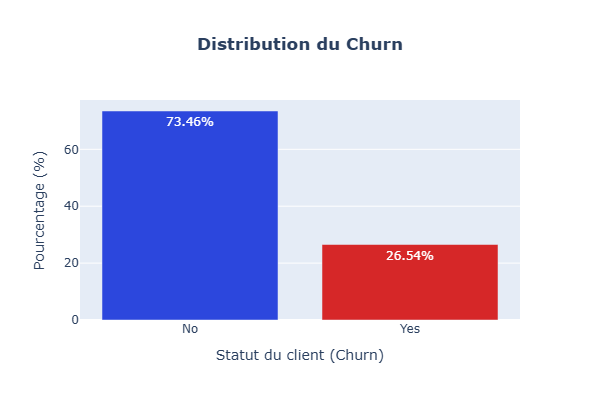

In [11]:
# Calcul des pourcentages
churn_counts = y_train.value_counts(normalize=True) * 100

# Construction du graphique avec plotly
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=churn_counts.index, 
        y=churn_counts.values,
        marker=dict(color=["#2C47DD", '#d62728']), # bleu pour Non-Churn, Rouge pour Churn
        # Ajout et formatage du texte des pourcentages qui sera affiché sur les barres
        text=[f"{val:.2f}%" for val in churn_counts.values],
        textposition='auto',
        name='Churn'
    )
)

# Personnalisation de la mise en page
fig.update_layout(
    width=600, 
    height=400,
    title_text="<b>Distribution du Churn</b>",
    xaxis_title="Statut du client (Churn)",
    yaxis_title="Pourcentage (%)",
    title_x=0.5 #centrer le titre
)

fig.show()


Le graphique montre que **73,46 %** des clients de l'ensemble d'entraînement sont restés, tandis que 26,54 % ont résilié leur abonnement. Il y a donc un déséquilibre modéré des classes de la variable cible.  
Ce constat important guidera nos choix pour la suite du projet :  
1. **`Choix des métriques`**: la précision (Accuracy) sera un indicateur trompeur. Nous évaluerons nos modèles en priorité via l'**AUC**, bien plus adapté aux classes déséquilibrées.   
2. **`Configuration des algorithmes`** : lors de la modélisation, nous pourrons ajuster des paramètres de poids des classes (comme class_weight='balanced' dans scikit-learn) pour aider les algorithmes à mieux apprendre la classe minoritaire.

### 3.2.2. Variables numériques 

Nous allons analyser la distribution des trois variables numériques de notre jeu d'entraînement **(Tenure, MonthlyCharges et TotalCharges)**.  Cette étape permet de comprendre visuellement la dispersion de nos données et de repérer d'éventuelles valeurs aberrantes.  
Pour cela, nous présentons ci-dessous les `boîtes à moustaches (boxplots)` pour nos trois variables continues, ainsi qu'un graphique en barres pour la variable binaire **SeniorCitizen**.

In [12]:
# Affichage des variables numériques
var_num = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Les variables numériques sont : {var_num}')

# Affichage des variables catégorielles
var_cat = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'Les variables catégorielles sont : {var_cat}')

Les variables numériques sont : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Les variables catégorielles sont : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


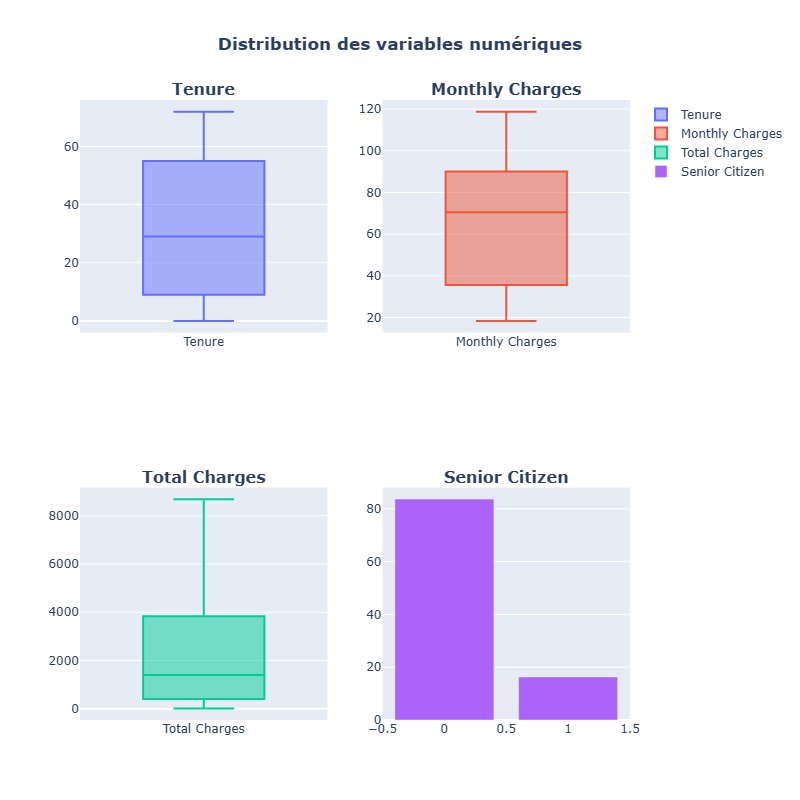

In [13]:
# Création d'une figure avec une disposition 2x2
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(f"<b>Tenure</b>", "<b>Monthly Charges</b>", "<b>Total Charges</b>", "<b>Senior Citizen</b>")
)

# Ajout des boxplots

fig.add_trace(
    go.Box(y=X_train["tenure"], name="Tenure"),
    row=1, col=1
)
fig.add_trace(
    go.Box(y=X_train["MonthlyCharges"], name="Monthly Charges"),
    row=1, col=2
)
fig.add_trace(
    go.Box(y=X_train["TotalCharges"], name="Total Charges"),
    row=2, col=1
)
#graphique en barres
fig.add_trace(
    go.Bar(name='Senior Citizen', x=X_train["SeniorCitizen"].value_counts(normalize=True).index, y=X_train["SeniorCitizen"].value_counts(normalize=True)*100),
    row=2, col=2
)
#Mise en page
fig.update_layout(
    title_text="<b>Distribution des variables numériques</b>",
    height=800, width=800,
    title_x=0.5 #centrer le titre
)

# Affichage
fig.show()

 L'examen des boîtes à moustaches confirme la dispersion analysée précédemment (section 2.3).  
 Le jeu de données ne contient aucune valeur aberrante (outliers) qui nécessiterait un traitement ou une suppression avant la modélisation.

### 3.2.3. Variables catégorielles

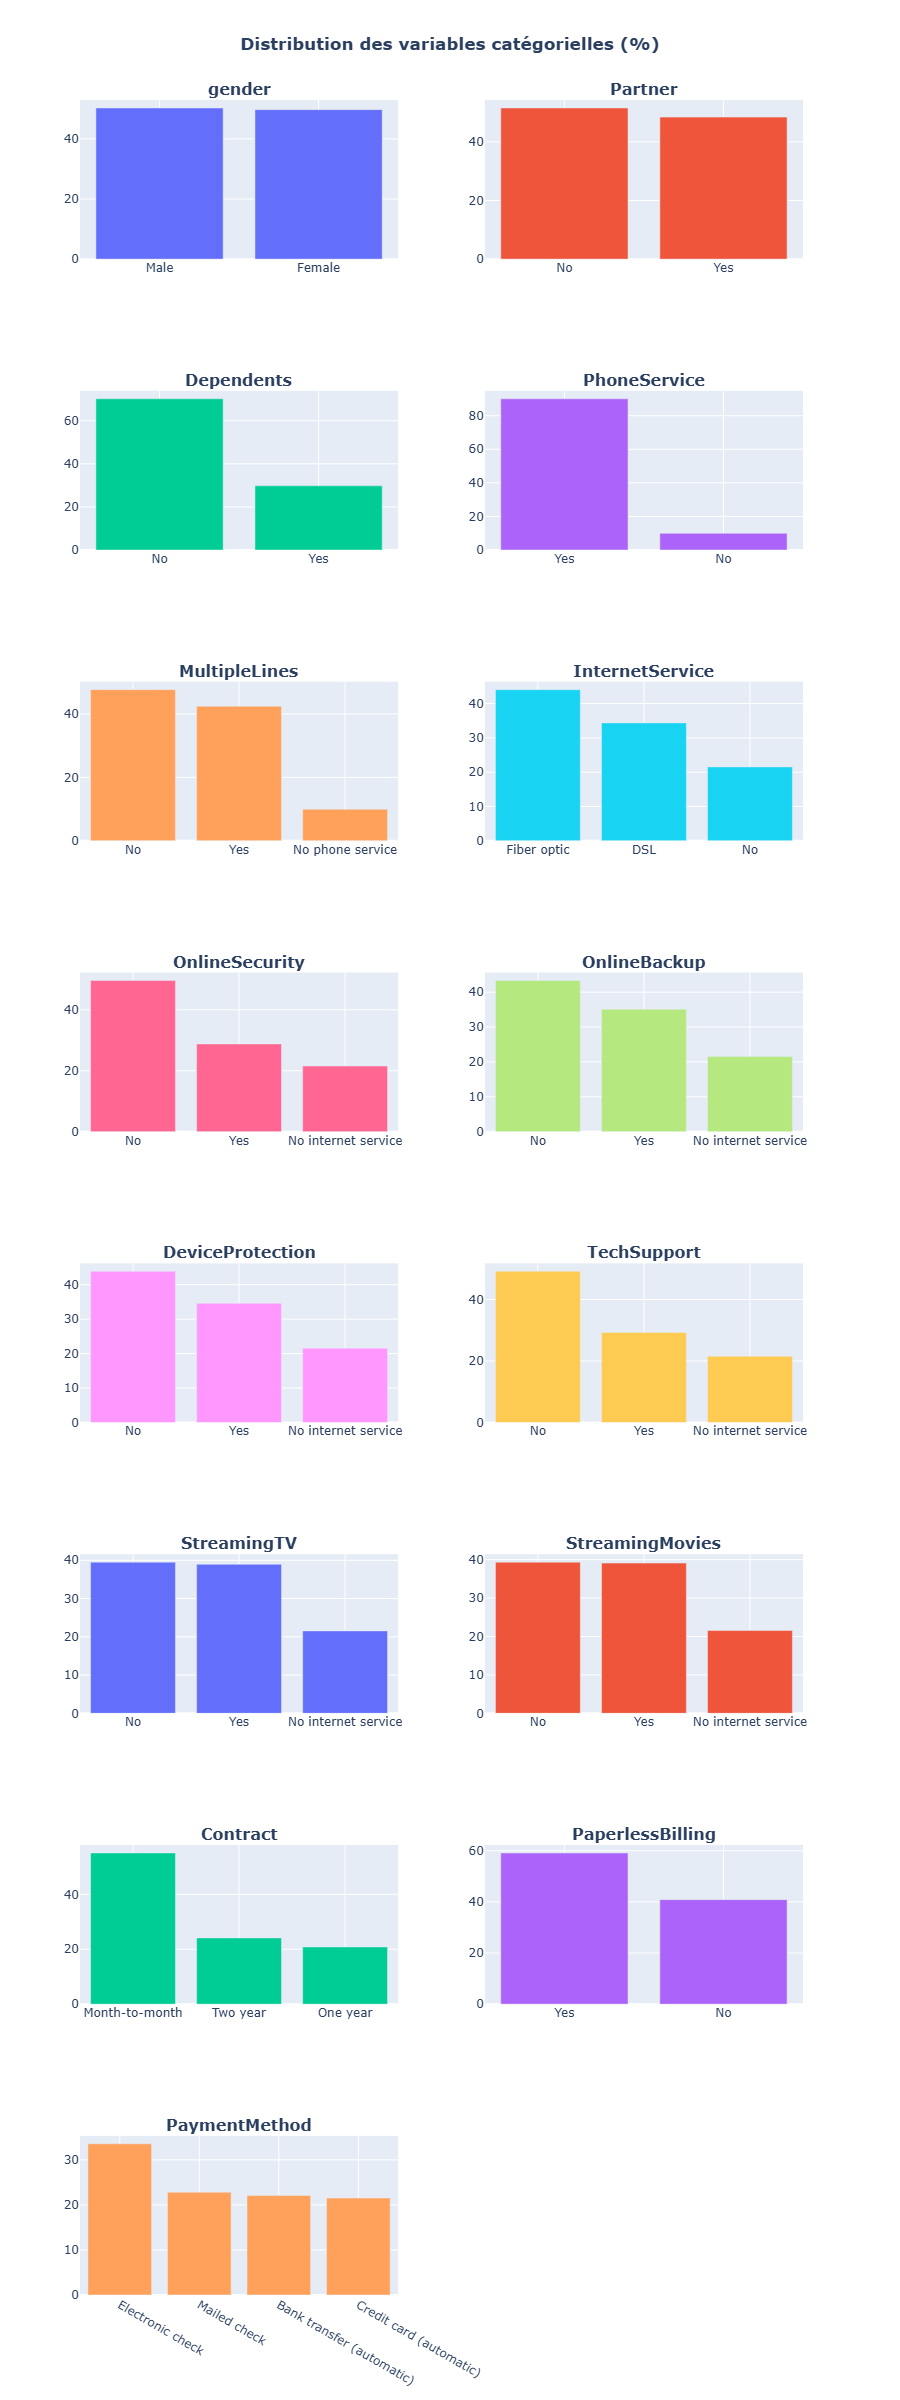

In [14]:
#graphique sur 2 colonnes
n_cols = 2
n_rows = (len(var_cat) + n_cols - 1) // n_cols #calcul du nombre de lignes

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f"<b>{col}</b>" for col in var_cat],
    horizontal_spacing=0.12,
    vertical_spacing=0.06
)

for i, column in enumerate(var_cat):
    row = i // n_cols + 1
    col = i % n_cols + 1

    counts = X_train[column].value_counts(normalize=True)*100

    fig.add_trace(
        go.Bar(
            x=[str(x) for x in counts.index],
            y=counts.values,
            name=column,
            #marker_color='#1f77b4',
            showlegend=False
    
        ),
        row=row,
        col=col
    )

fig.update_layout(
    title_text='<b>Distribution des variables catégorielles (%)</b>',
    width=900,
    height=max(300, 300 * n_rows),
    title_x=0.5 #centrer le titre
)
fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)
fig.show()

L'examen visuel des distributions des variables catégorielles permet de voir les caractéristiques majeures du profil des clients :  
1. **Type de service** : une grande majorité de clients bénéficie du service téléphonique (PhoneService). Concernant Internet (InternetService), la fibre optique représente une part très importante des abonnements par rapport au DSL. Les options de sécurité (OnlineSecurity) et d'assistance (TechSupport) restent cependant minoritaires.  
2. **Structure contractuelle** : les abonnements contractuels (Contract) sont fortement dominés par l'engagement Mois par mois (Month-to-month), ce qui offre une grande flexibilité aux clients mais expose l'entreprise à des pertes financières.    
3. **Modalitiés de facturation et de paiement**: la facturation dématérialisée (PaperlessBilling) est largement adoptée. Le mode de paiement (PaymentMethod) par Chèque électronique (Electronic check) est particulièrement prédominant face aux autres méthodes automatisées (virement ou carte de crédit).  

Cette vision globale met en lumière les clients à risque (abonnements courts sans engagement, forte présence de la fibre souvent plus coûteuse), que nous allons analyser en détail dans la section des statistiques bivariées.

## 3.3. Statistiques bivariées : analyses croisées avec le Churn

 Après avoir étudié chaque variable indépendamment, nous allons maintenant analyser leurs relations directes avec le Churn. L'objectif est d'identifier les facteurs contractuels, financiers et de services qui influencent le plus la décision de résiliation des clients.

### 3.3.1. Variables numériques vs Churn

##### a. Distribution des frais mensuels (MonthlyCharges) selon le churn

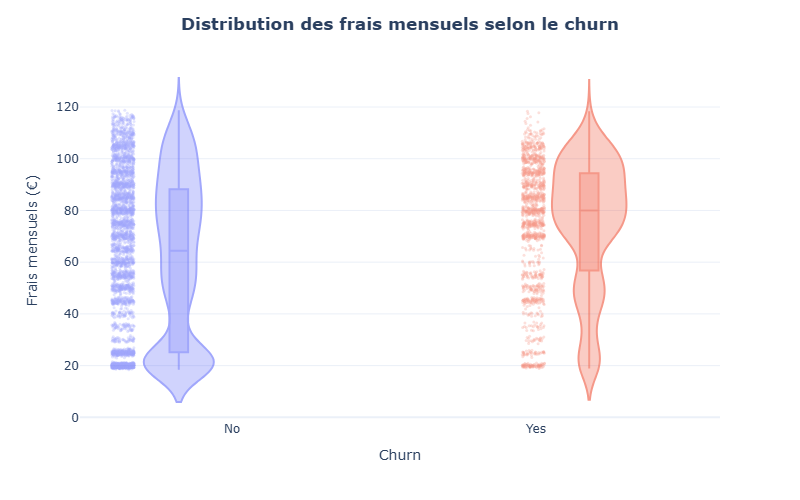

In [15]:
fig = px.violin(
    X_train, 
    x=y_train, 
    y="MonthlyCharges", 
    color=y_train, 
    box=True,          # Intègre la boîte à moustaches à l'intérieur du violon
    points="all",      # Ajoute les points à l'intérieur
    width=800,
    height=500,
    template="plotly_white"
)
# Configuration de la transparence
fig.update_traces(
    opacity=0.6,        # couleur du violin plus transparente
    marker=dict(
        opacity=0.3,    # points individuels plus transparents
        size=3          # taille des points
    )
)
# Mise en page centrée
fig.update_layout(
    title=dict(
        text="<b>Distribution des frais mensuels selon le churn</b>", 
        x=0.5, #pour centrer le titre
        xanchor='center'
    ),
    xaxis_title="Churn",
    yaxis_title="Frais mensuels (€)",
    template="plotly_white",
    showlegend=False
)
fig.show()

Le graphique en violon met en évidence une différence de comportement majeure entre les deux groupes de clients :
* **Clients actifs (Churn=No)** : on observe une forte concentration de clients avec des frais très bas (autour de 20 €), correspondant aux offres d'entrée de gamme ou mobiles seuls, qui ne résilient presque jamais.  
* **Clients ayant résilié (Churn=Yes)** : la distribution est fortement concentrée vers le haut, avec un pic majeur entre `70 et 100 €` par mois (médiane à 80 €).  
On peut en conclure que les tarifs élevés constituent un déclencheur majeur du churn. Les clients payant les abonnements les plus chers (généralement la fibre optique avec options) se désabonnent plus.

#### b. Distribution de frais totaux (TotalCharges) selon le Churn

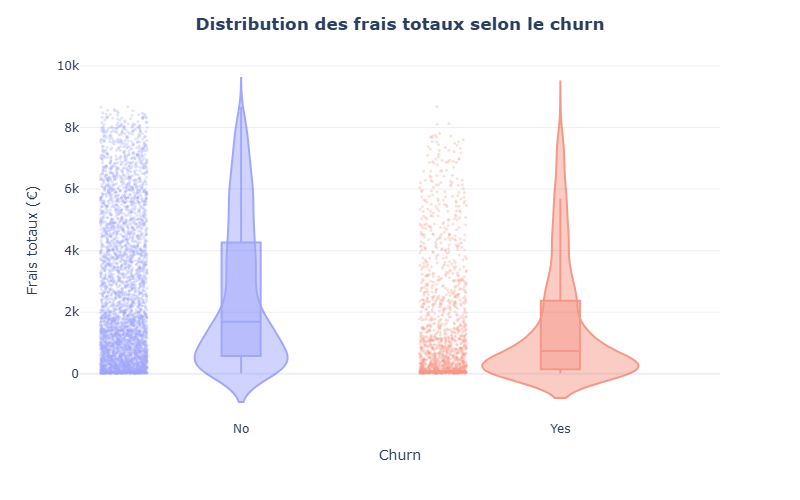

In [25]:
fig = px.violin(
    X_train, 
    x=y_train, 
    y="TotalCharges", 
    color=y_train, 
    box=True,          # Intègrer la boîte à moustaches à l'intérieur du violon
    points="all",      # Ajouter les points à l'intérieur
    width=800,
    height=500,
    template="plotly_white"
)
# Configuration de la transparence
fig.update_traces(
    opacity=0.6,        # opacité pour le violin
    marker=dict(
        opacity=0.3,    # opacité des points
        size=3          # taille des points
    )
)
# Mise en page centrée
fig.update_layout(
    title=dict(
        text="<b>Distribution des frais totaux selon le churn</b>", 
        x=0.5, #pour centrer le titre
        xanchor='center'
    ),
    xaxis_title="Churn",
    yaxis_title="Frais totaux (€)",
    template="plotly_white",
    showlegend=False
)
fig.show()

* **Clients actifs (Churn=No)** : la distribution est très étalée vers le haut, avec de nombreux clients cumulant des montants élevés (jusqu'à 8 000 € et plus). Le montant médian se situe quant à lui aux alentours de 1 700 €. On observe également une forte concentration de points tout en bas du violon (en dessous de 1 000 €), représentant les nouveaux clients récents qui n'ont pas encore résilié. 
* **Clients ayant résilié (Churn=Yes)** : Le violon rouge est dense en bas, très proche de 0, avec une médiane basse (autour de 700 €). La distribution s'écrase très rapidement dès que l'on monte dans les prix.   
On peut en conclure que les clients insatisfaits résilient massivement au cours de leurs premiers mois d'abonnement, avant d'avoir pu accumuler une facturation totale importante.

#### c. Distribution de l'ancienneté (Tenure) selon le churn

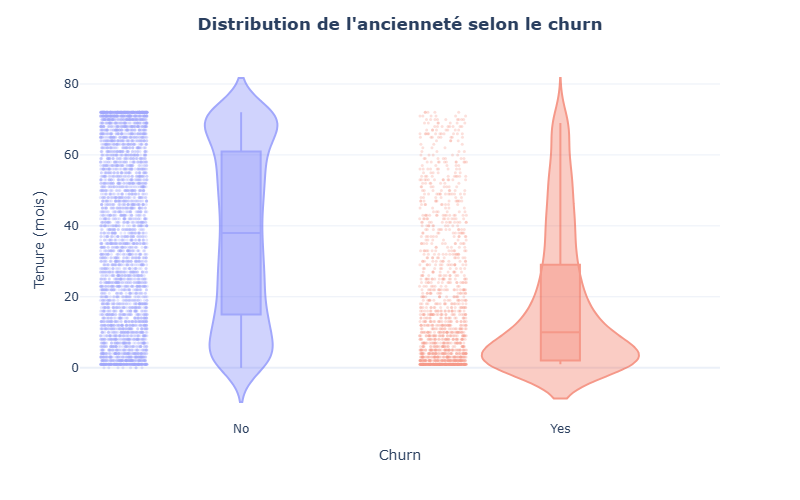

In [26]:
fig = px.violin(
    X_train, 
    x=y_train, 
    y="tenure", 
    color=y_train, 
    box=True,        
    points="all",    
    width=800,
    height=500,
    template="plotly_white"
)
# Configuration de la transparence
fig.update_traces(
    opacity=0.6,      
    marker=dict(
        opacity=0.3, 
        size=3        
    )
)
# Mise en page centrée
fig.update_layout(
    title=dict(
        text="<b>Distribution de l'ancienneté selon le churn</b>", 
        x=0.5, #pour centrer le titre
        xanchor='center'
    ),
    xaxis_title="Churn",
    yaxis_title="Tenure (mois)",
    template="plotly_white",
    showlegend=False
)
fig.show()

L'examen de la distribution de la variable Tenure confirme de manière indiscutable l'hypothèse précédente :**`"le risque de churn est maximal au départ"`**.  
Une proportion écrasante de clients qui quittent l'opérateur le font au cours de leurs tout premiers mois d'abonnement, avec un pic massif concentré entre ``0 et 6 mois`.  
**L'effet "barrière" du temps** : plus un client dépasse le cap de la première année, plus sa probabilité de résilier diminue. Passé 40 mois d'ancienneté, le churn devient marginal.

#### d. Analyse conjointe des variables numériques (pairplot)

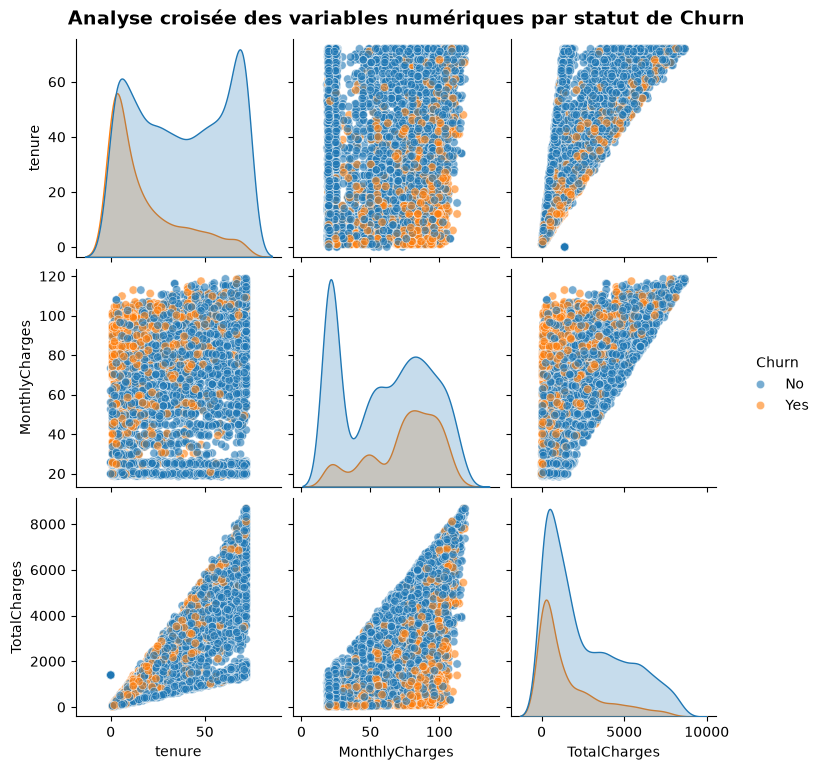

In [18]:
# On rassemble X_train et y_train temporairement pour le graphique
df_pairplot = X_train[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_pairplot['Churn'] = y_train

im = sns.pairplot(df_pairplot, hue='Churn', vars=['tenure', 'MonthlyCharges', 'TotalCharges'], plot_kws={'alpha': 0.6})
im.fig.suptitle("Analyse croisée des variables numériques par statut de Churn", y=1.02, fontsize=14, fontweight='bold')
plt.savefig(f"../reports/figures/pairplot_numvar.png", dpi=300, bbox_inches="tight")
plt.show()

Le pairplot confirme visuellement la forte interaction entre nos trois variables numériques et le Churn. Deux zones de dispersion se distinguent très nettement :

1. **Le Nuage de Churn (Points oranges)** : sur le croisement **MonthlyCharges vs tenure**, on observe une concentration massive de points oranges tout en haut à gauche. Cela matérialise parfaitement le profil des clients récents (**tenure** bas) mais payant des tarifs très élevés (**MonthlyCharges** > 70 €).  
2. **La zone des clients actifs (Points bleus)** : les clients restés fidèles (Churn='No') se regroupent principalement le long de l'axe de forte ancienneté (**tenure** élevé), ainsi que sur une bande horizontale basse représentant les petits forfaits.  

Ce graphique valide le fait que l'ancienneté et le montant mensuel sont les deux plus puissants prédicteurs numériques du Churn. Nous pouvons maintenant passer à l'analyse des variables catégorielles pour comprendre quels types de contrats et de services favorisent ce comportement.


### 3.3.2. Variables catégorielles vs Churn

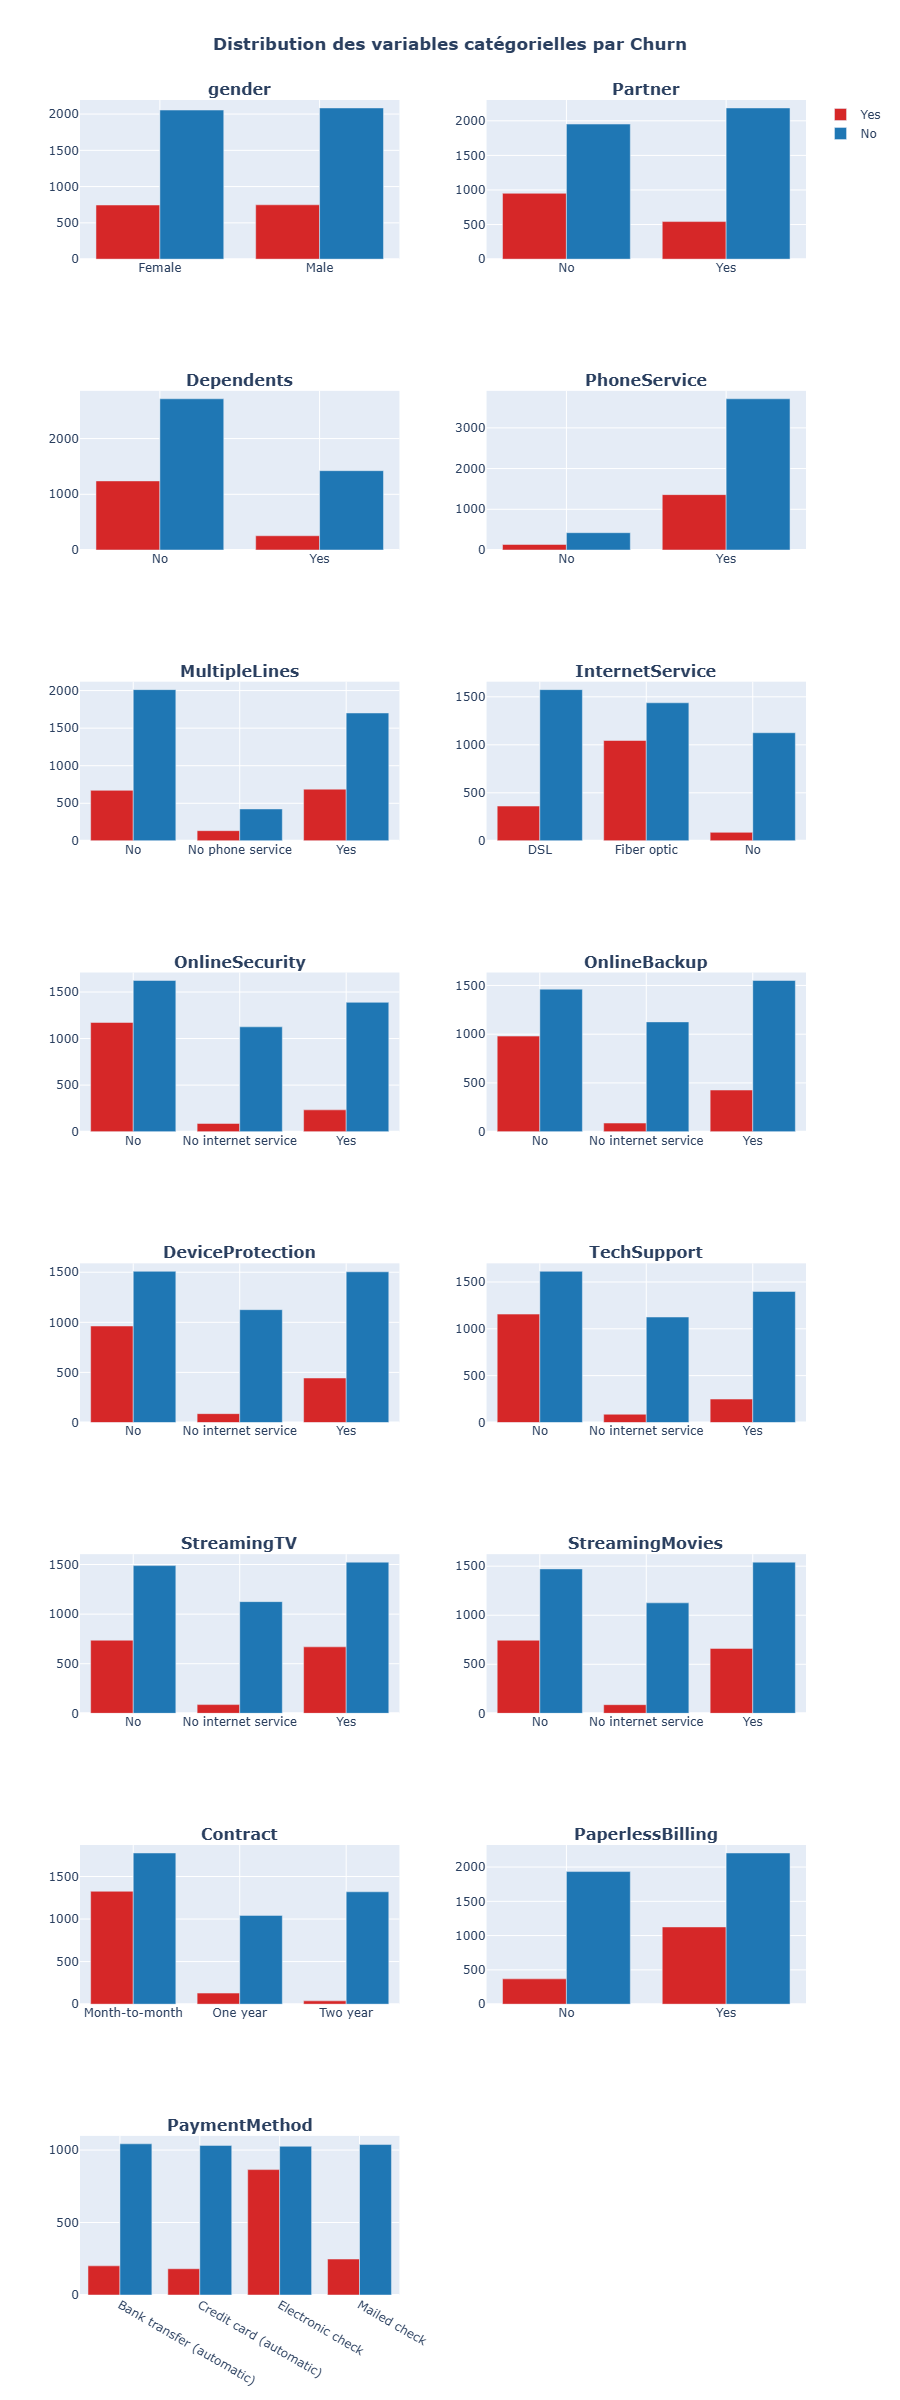

In [27]:
#graphiques sur 2 colonnes et plusieurs lignes
n_cols = 2
n_rows = (len(var_cat) + n_cols - 1) // n_cols
df_barplot = X_train[var_cat].copy()
df_barplot['Churn'] = y_train

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f"<b>{col}</b>" for col in var_cat],
    horizontal_spacing=0.12,
    vertical_spacing=0.06
)
for i, column in enumerate(var_cat):
    row = i // n_cols + 1
    col = i % n_cols + 1

    # counts par modalité x Churn
    counts = df_barplot.groupby([column, 'Churn']).size().unstack()
    percentages = (counts.T / counts.sum(axis=1)).T * 100 # Calcul précis par ligne/catégorie
    # ajouter une trace par valeur de Churn si présente
    for churn_value, color in [('Yes', '#d62728'), ('No', '#1f77b4')]:
        if churn_value in counts.columns:
            y_values = counts[churn_value]
            y_pct_values = percentages[churn_value]
            fig.add_trace(
                go.Bar(
                    x=[str(x) for x in counts.index],
                    y=y_values,
                    name=churn_value,
                    marker_color=color,
                    showlegend=(i == 0),# légende une seule fois
                    # Ajout du pourcentage mais sans l'afficher sur les barres pour un rendu plus propre
                    text=[f"{val:.2f}%" for val in y_pct_values], # Formate le texte (ex: 26.52%)
                    textposition='none', # Pas d'affichage sur la barre
                    hovertemplate=f"<b>%{{x}}</b><br>Volume : %{{y}}<br>Pourcentage : %{{text}}<extra>{churn_value}</extra>"
                ),
                row=row,
                col=col
            )

fig.update_layout(
    title_text='<b>Distribution des variables catégorielles par Churn</b>',
    #x=0.5, #pour centrer le titre
    #xanchor='center',
    barmode='group',
    width=900,
    height=max(300, 300 * n_rows),
    #template='plotly_white',
    legend=dict(x=1.02, y=1.0),
    title_x=0.5 #centrer le titre
)

fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)
fig.show()

L'analyse croisée des graphiques permet de cartographier précisément le profil des clients qui résilient :  

1. **L'aspect contractuel et financier (facturation)** : le churn est massivement concentré chez les clients sans engagement (*Month-to-month*), ceux ayant opté pour la facturation en ligne (*PaperlessBilling*) et ceux utilisant le chèque électronique comme mode de paiement.  
2. **L'aspect technique (services Internet et options)** : les clients équipés d'une connexion internet (qu'ils aient l'option *StreamingTV* ou non) affichent un taux de churn élevé (30 à 33 %), ce qui confirme que le problème vient du coût du service internet (principalement la fibre). En revanche, les options de protection et d'assistance (*OnlineSecurity* = Yes et *TechSupport* = Yes) sont les seules qui réduisent le taux de churn. Enfin, les clients sans internet (*No internet service*) sont les plus stables de l'entreprise.  
3. **Le facteur démographique (profil du foyer)** : la structure familiale joue un rôle majeur dans la fidélisation. Les clients célibataires et sans attache familiale (*Partner* = No et *Dependents* = No) sont des profils à risque, avec des taux de churn dépassant les 31 %. À l'inverse, le fait de vivre en couple (*Partner* = Yes) et d'avoir des personnes à charge (*Dependents* = Yes) stabilise fortement la relation commerciale. Le taux de résiliation tombe à seulement 15 % pour les foyers familiaux, car la logistique de changement d'opérateur et le risque de coupure internet impactent le quotidien de tout le foyer.
4. **L'aspect neutre (téléphonie)** : bien que le volume absolu de résiliations soit plus élevé chez les abonnés au service téléphonique (*PhoneService* = Yes) en raison de leur supériorité numérique dans le jeu de données, le taux de churn en pourcentage reste identique (environ 26 %) qu'ils disposent ou non de ce service. La présence de services téléphoniques ou de lignes multiples n'influence donc pas le niveau de risque.


### 3.3.3. Variables catégorielles vs variables numériques vs Churn

#### a. Frais totaux vs service Internet
Le graphique suivant permet de faire une analyse croisée des frais totaux (TotalCharges) par type de service Internet (InternetService) et le "Churn" 

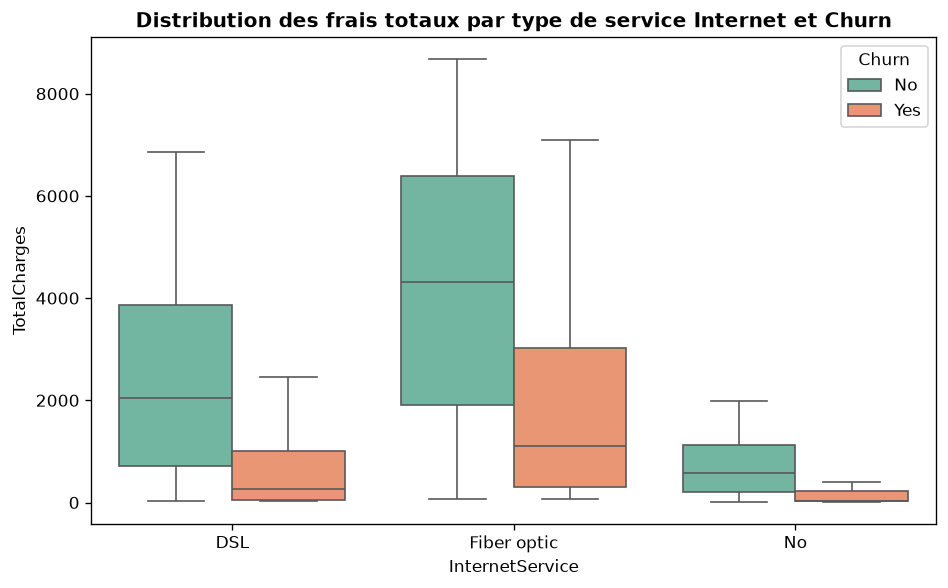

In [20]:
plt.figure(figsize=(8, 5), dpi=120)
sns.boxplot(
    data=X_train,
    x="InternetService",
    y="TotalCharges",
    order=["DSL", "Fiber optic", "No"],
    palette="Set2",
    hue=y_train,
    showfliers=False,
    linewidth=1.0
)
plt.title("Distribution des frais totaux par type de service Internet et Churn", weight="bold")
plt.tight_layout()
plt.savefig(f"../reports/figures/Distribution_fraistotaux_Internet_Churn.png", dpi=300, bbox_inches="tight")
plt.show()

Ce graphique apporte des conclusions stratégiques majeures sur la valeur financière du Churn : 
* Les abonnés à la **fibre optique** représentent la plus forte source de revenus cumulés (TotalCharges très élevées). Cependant, lorsqu'ils décident de partir (Churn = Yes), ils le font en ayant déjà accumulé des montants bien plus importants (boîte orange s'étendant jusqu'à **3 000 €**). Le coût financier de cette perte est donc critique pour l'entreprise.  
* Quelle que soit la technologie choisie (DSL ou Fibre), la médiane des frais totaux des clients qui résilient reste très inférieure à celle des clients qui restent. Cela valide définitivement le fait que la rupture contractuelle se produit majoritairement de manière précoce dans le cycle de vie du client (faible ancienneté). 
* Les clients sans abonnement Internet (No) n'engendrent presque aucun frais cumulé et affichent un Churn quasi nul, confirmant leur profil de consommateurs traditionnels et fidèles.  

Ce croisement démontre que l'entreprise perd ses clients sur le segment le plus rentable (la fibre), ce qui peut avoir un impacte lourd sur le chiffre d'affaires.

#### b. Frais mensuels selon le mode de paiement
Le graphique suivant permet de voir la relation entre le prix, le mode de paiement et le départ du client.

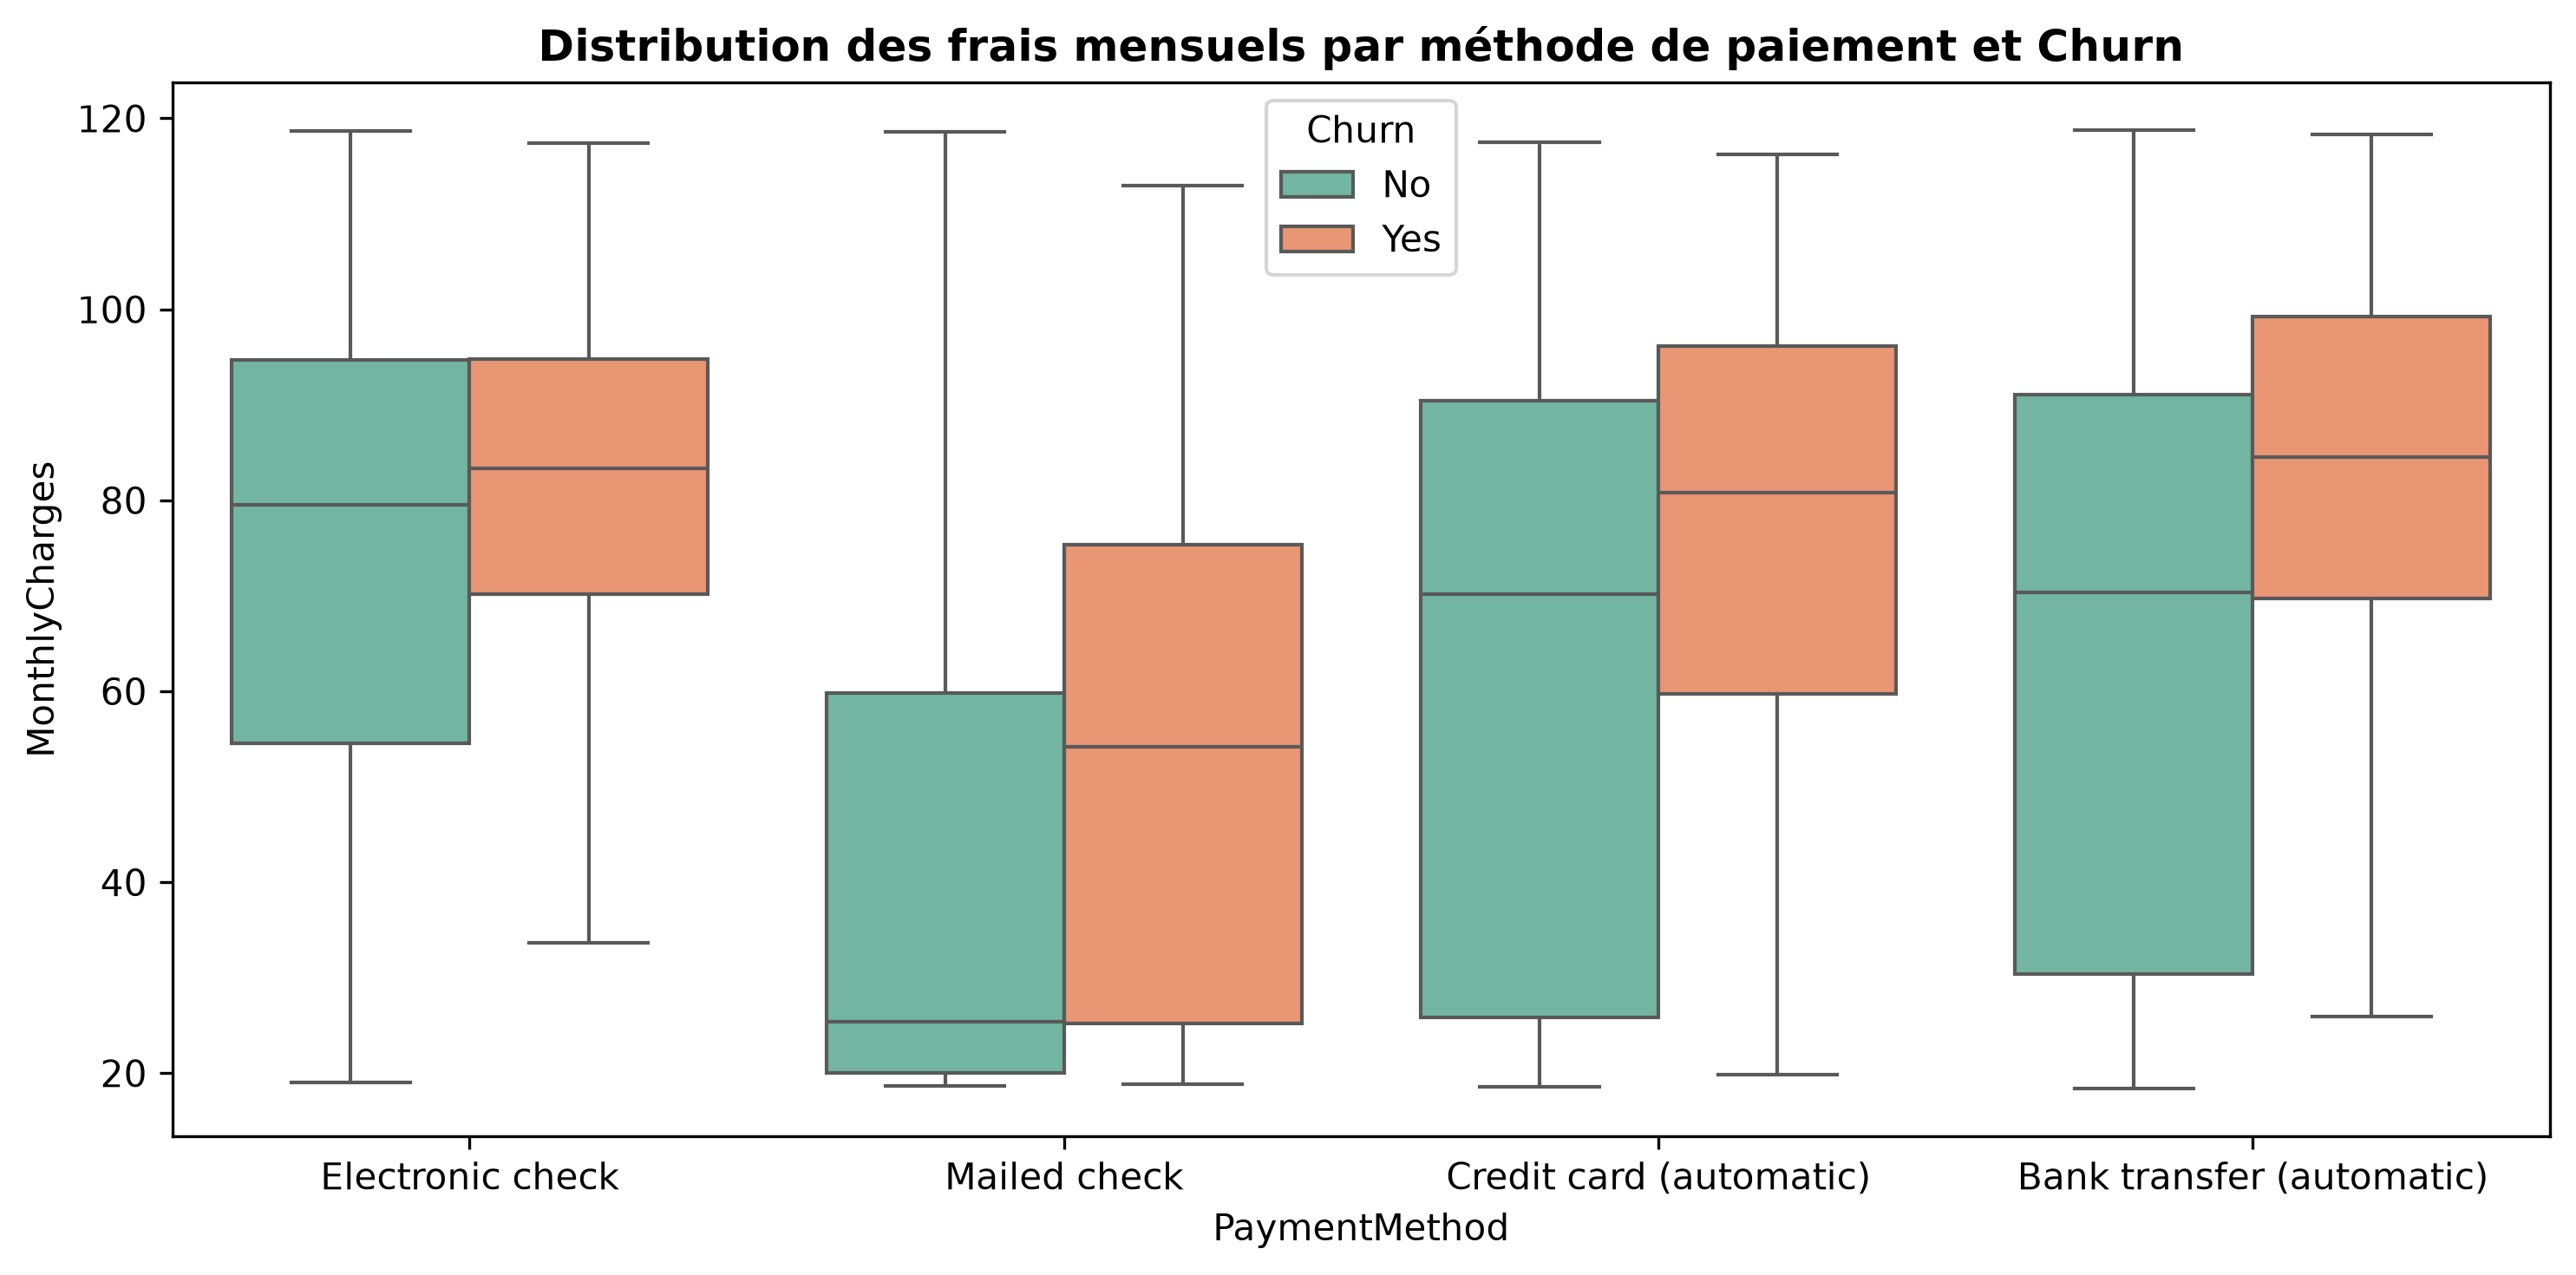

In [21]:
plt.figure(figsize=(10, 5), dpi=300)
sns.boxplot(
    data=X_train,
    x="PaymentMethod",
    y="MonthlyCharges",
    palette="Set2",
    hue=y_train,
    showfliers=False,
    linewidth=1.0
)
plt.title("Distribution des frais mensuels par méthode de paiement et Churn", weight="bold")
plt.tight_layout()
plt.savefig(f"../reports/figures/Distribution_fraismensuels_moyenP_Churn.png", dpi=300, bbox_inches="tight")
plt.show()

L'examen de ces boîtes à moustaches nous permet de comprendre les mécanismes financiers cachés derrière les modes de paiement :  
* **`Le chèque postal (Mailed check)`** : mode stable uniquement pour les petits forfaits (**médiane à 25 €)**. Pour les prix plus élevés les clients préfèrent d'autres mode de paiement. On le voit bien sur la boîte orange des clients qui résilient **(médiane à 55 €)**.  
* **`Le chèque électronique (Electronic check)`** : les boîtes verte et orange sont toutes deux situées très haut, avec des médianes très serrées (**entre 80 et 85**) . Ce mode de paiement est donc associé aux abonnements les plus coûteux, ce qui explique pourquoi il concentre le plus gros volume de churners du projet.  
* **`Les modes automatiques (Credit card & Bank transfer)`** : le prélèvement automatique démontre une efficacité redoutable pour fidéliser la clientèle. Les boîtes vertes s'étirent de manière continue sur l'ensemble de l'échelle des prix (des tarifs les plus bas à environ **25 €** jusqu'aux abonnements les plus élevés à plus de **100 €**).     L'automatisation fluidifie tellement l'expérience de facturation qu'elle sécurise les clients à tous les niveaux de tarifs.  
La boîte orange du churn se détache légèrement vers le haut, rappelant simplement que la pression tarifaire maximale reste un facteur de vigilance, mais l'effet protecteur de l'automatisation demeure le constat principal.

 #### c. Frais mensuels selon le type de contrat
Le graphique qui suit parfait étudie le lien entre le prix, la barrière contractuelle et le churn.

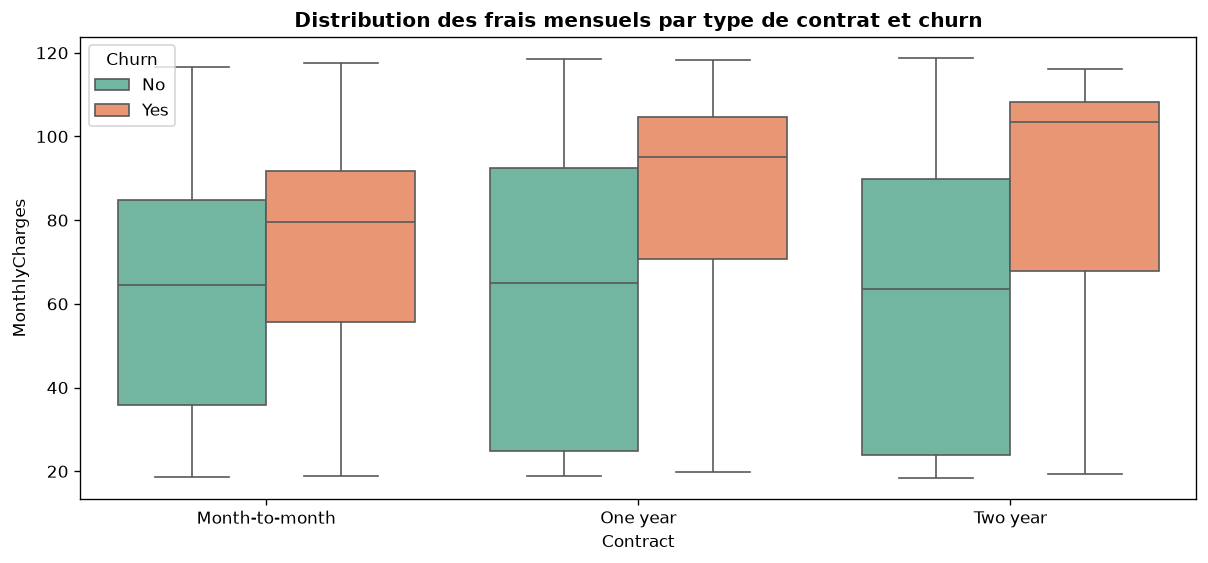

In [22]:
plt.figure(figsize=(12, 5), dpi=120)
ax = sns.boxplot(
    data=X_train,
    x="Contract",
    y="MonthlyCharges",
    order=['Month-to-month', 'One year', 'Two year'],
    palette="Set2",
    hue=y_train,
    showfliers=False,
    #linewidth=1.0
)
plt.title("Distribution des frais mensuels par type de contrat et churn", weight="bold")
#plt.tight_layout()
ax.legend(title="Churn")
plt.savefig(f"../reports/figures/Distribution_fraismensuels_ContratT_Churn.png", dpi=300, bbox_inches="tight")
plt.show()

L'étude de ce graphique apporte une nuance fondamentale sur l'efficacité des contrats d'engagement face à la pression tarifaire :

* **L'effet de rupture sur les contrats à long terme** : pour les contrats d'un an (One year) et de deux ans (Two year), la boîte orange (Yes) monte nettement, avec une médiane supérier à **95 €**. Cela montre que même les clients censés être les plus stables (engagés) finissent par résilier si le coût de leur abonnement mensuel devient trop élevé.  
* **Le churn d'opportunité sur le Mois par mois** : sur le segment Month-to-month, la boîte orange dépasse aussi la boîte verte. Cependant, l'écart est moins marqué. Comme ces clients peuvent partir à tout moment, une facture juste un peu au-dessus de la médiane, vers **80 €**, suffit à les faire partir tout de suite.  

 L'engagement contractuel ne protège pas totalement contre le Churn. Dès que les frais mensuels dépassent le seuil critique de 80 à 90 €, le risque de résiliation augmente fortement, même pour les clients engagés sur le long terme. Le prix reste le déclencheur principal de l'attrition.

## 4. Matrice de corrélation

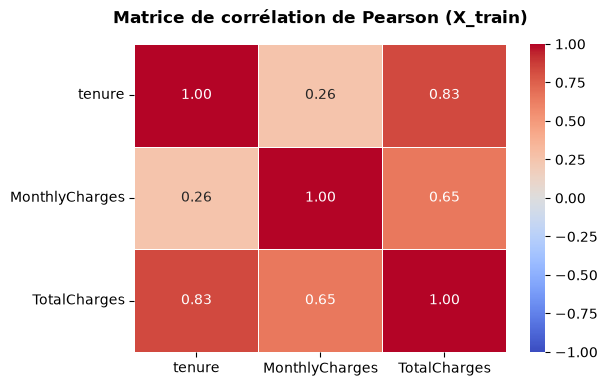

In [23]:
# Sélection des trois variables numériques continues de l'ensemble d'entraînement
df_corr = X_train[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()

# Calcul des coefficients de corrélation de Pearson
matrix_corr = df_corr.corr()

# Configuration et affichage de la Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    matrix_corr, 
    annot=True,          # Affiche les coefficients
    cmap='coolwarm',     # Palette Bleu (négatif) à Rouge (positif)
    fmt=".2f",           # Arrondi propre à 2 décimales
    vmin=-1, vmax=1,     # Échelle mathématique stricte pour la corrélation
    linewidths=0.5       # Ligne blanche discrète de séparation
)

plt.title("Matrice de corrélation de Pearson (X_train)", fontsize=12, fontweight='bold', pad=15)
plt.savefig(f"../reports/figures/Matrice_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


La matrice de corrélation met en évidence des relations mathématiques très fortes :
* **`TotalCharges et Tenure (~0,83) `**: corrélation positive élevée quasi linéaire. 
Plus un client a de l'ancienneté, plus le montant cumulé de ses factures est élevé.  
* **`TotalCharges et MonthlyCharges (~0,65)`** : corrélation modérée, les clients avec des forfaits chers font grimper beaucoup plus le montant total accumulé.  
* **`Tenure et MonthlyCharges (~0,25)`** : coefficient faible, indiquant l'absence de relation linéaire simple entre l'ancienneté et le prix du forfait mensuel. Cela s'explique par la présence simultanée de clients historiques sur de vieilles offres économiques et d'autres avec des forfaits haut de gamme.

## 4.1 Etude de la variables d'ancienneté (Tenue)
La matrice de corrélation a montré une forte corrélation entre les variables TotalCharges et Tenure.
Ces dernières sont d'une très grande importante pour la suite de notre étude. Elles ont un lien très étroit avec le Churn.
Nous allons découper la variable "tenure" par tranches d'une année pour une étude plus fine de cette variable.

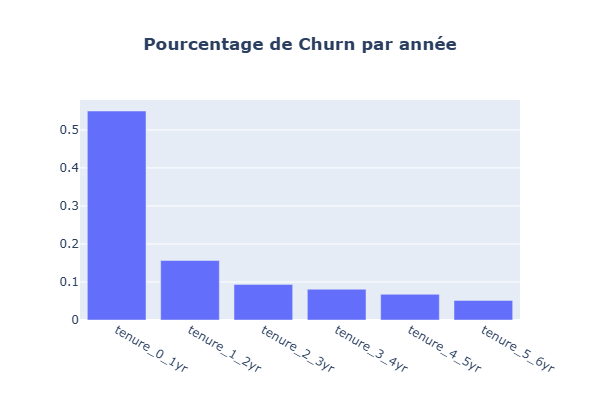

In [28]:
# Création de tranches d'années (ex: 0-12 mois = 'tenure_0_1yr')
bins = [0, 12, 24, 36, 48, 60, X_train['tenure'].max()]
labels = ['tenure_0_1yr', 'tenure_1_2yr', 'tenure_2_3yr', 'tenure_3_4yr', "tenure_4_5yr", "tenure_5_6yr"]

# Nouvelle variable catégorielle 'tenure_tranches'
X_train['tenure_tranches'] = pd.cut(X_train['tenure'], bins=bins, labels=labels, include_lowest=True)
X_train['Churn']=y_train

#Recupérer les lignes avec Churn = 'Yes'
X_train_churn = X_train[X_train['Churn']=='Yes']

#Extraire les colonnes 'tenure_tranches' et 'Churn' dans un nouveau DataFrame
df_temp = X_train_churn[['tenure_tranches', 'Churn']]

#Représentation graphique
index=labels
y=df_temp['tenure_tranches'].value_counts()

fig = go.Figure()
fig.add_trace(
   go.Bar(name='tenure_tranches', x=index, y=df_temp['tenure_tranches'].value_counts(normalize=True))
)
fig.update_layout(
    width=600, height=400,
    title_text="<b>Pourcentage de Churn par année</b>",
    title_x=0.5
)
fig.show()



Ce graphique confirme que le Churn est plus répondu chez les nouveaux clients (**55%** de clients).
Nous allons utiliser cette nouvelle variable catégorielle (tenure_tranches) dans le notebook III lors du Feature Enginnering. 
# Conclusion
Dans ce notebook, nous avons vérifié nos données et identifier les relations entre les caractéristiques des clients et la cible. Nous savons désormais quelles sont les variables les plus prometteuses pour la suite.  
Dans le prochain notebook, nous allons construire notre premier modèle de référence.